In [4]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS

from tqdm import tqdm

In [6]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [7]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [8]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [9]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [10]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


In [11]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2


In [12]:
from scipy.spatial import cKDTree

# Grid / plotting window in ecliptic-rate space
xlim = (-0.8, 0.8)   # v_lambda range [deg/day]
ylim = (-0.8, 0.8)   # v_beta   range [deg/day]

# Uniform grid spacing
# 0.01 as grid step
grid_step = 0.01

# Grid coordinates
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)

# 2D mesh of evaluation points
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")

# Flattened list of evaluation points: shape (Ngrid, 2)
grid_points = np.column_stack([X0.ravel(), Y0.ravel()])

print("Grid shape:", X0.shape)
print("Number of evaluation points:", len(grid_points))

Grid shape: (161, 161)
Number of evaluation points: 25921


In [13]:
from math import lgamma
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp


# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


In [14]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

In [15]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

In [16]:
# Evaluate full-posterior density on the whole grid

from tqdm import tqdm

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

In [17]:
k_map = 10
n_d0_grid_map = 400

In [18]:
# Population dataframes for cloning / per-population workflows
s3m_mba = s3m
s3m_neo = neo
s3m_tno = tno
s3m_tjn = trojan  

In [19]:

# Clone a population by randomizing mean anomaly at obstime

import gc
import numpy as np
from scipy.spatial import cKDTree
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2

def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times by assigning a random mean anomaly
    at obstime_str. Keeps a,e,i,node,argperi fixed and changes only orbital phase
    via t_p.

    Returns repeated orbital element arrays.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    a_AU   = df["a"].to_numpy(dtype=np.float32)
    e      = df["e"].to_numpy(dtype=np.float32)
    inc    = df["i"].to_numpy(dtype=np.float32)
    raan   = df["node"].to_numpy(dtype=np.float32)
    argp   = df["argperi"].to_numpy(dtype=np.float32)

    # repeat fixed elements
    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep    = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_rep.astype(np.float64) * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km**3))
    n_rad_day = n_rad_s * 86400.0

    # random mean anomaly at observation epoch
    M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep)).astype(np.float64)

    # choose perihelion time so that M(obstime)=M_rand
    tp_new = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)

    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new

In [20]:
# Convert orbital elements -> vlam, vbeta using your existing pipeline
# but with a configurable sky center in ecliptic lon/lat

def elements_to_vlam_vbeta(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import (
        SkyCoord, GCRS, get_sun, GeocentricTrueEcliptic
    )

    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and RA/Dec rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg  = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    # object sky coords in GCRS
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    # choose center of the sky cut
    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg

    m = sep <= max_sep_deg
    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg, dec_deg,
        dra_deg_day, ddec_deg_day,
        obstime_str
    )

    finite = np.isfinite(vlam) & np.isfinite(vbeta)
    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)

    return vlam, vbeta

In [21]:

# Clone configuration (less memory intensive)

clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,   # first test: no MBA cloning yet
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

rng = np.random.default_rng(42)
overlay_max = 100_000

In [22]:
# Build cloned rate-space populations one at a time
# Keeps only small overlay samples + final maps

clone_overlay = {}
clone_density_maps = {}
clone_density_maps_downweighted = {}

for pop_name, info in clone_sources.items():
    f = info["clone_factor"]
    df = info["df"]

    print(f"\nCloning {pop_name} with factor {f}...")

    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
        df, clone_factor=f, obstime_str=obstime_str, rng=rng
    )
    print("  cloned orbit count:", len(a_rep))

    vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
        obstime_str=obstime_str,
        scorer=info["scorer"],
        max_sep_deg=max_sep_deg,
        chunk=100_000,
        show_progress=True,
    )
    print(f"  final cloned visible points: {len(vlam_clone)}")

    # raw element arrays no longer needed
    del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
    gc.collect()

    # keep only a small random subset for plotting overlays
    n_overlay = min(overlay_max, len(vlam_clone))
    idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
    clone_overlay[pop_name] = {
        "vlam": vlam_clone[idx_overlay].copy(),
        "vbeta": vbeta_clone[idx_overlay].copy(),
        "scatter_size": info["scatter_size"],
        "scatter_alpha": info["scatter_alpha"],
    }

    pts_clone = np.column_stack([vlam_clone, vbeta_clone])
    tree_clone = cKDTree(pts_clone)

    density_clone_flat = evaluate_density_map_full_posterior_2d(
        tree_clone,
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_clone_map = density_clone_flat.reshape(X0.shape)
    density_downweighted_map = density_clone_map / f

    clone_density_maps[pop_name] = density_clone_map
    clone_density_maps_downweighted[pop_name] = density_downweighted_map

    print(f"{pop_name} done.")
    print("  raw cloned max density   :", np.nanmax(density_clone_map))
    print("  downweighted max density :", np.nanmax(density_downweighted_map))

    # cleanup large arrays before next population
    del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
    gc.collect()


Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.18it/s]


  final cloned visible points: 1418518


Evaluating density map: 100%|██████████| 25921/25921 [08:11<00:00, 52.70it/s]


MBA done.
  raw cloned max density   : 393660850.11085695
  downweighted max density : 393660850.11085695

Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 4990382200.988374
  downweighted max density : 499038220.0988374

Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.60it/s]


  final cloned visible points: 221533


Evaluating density map: 100%|██████████| 25921/25921 [08:08<00:00, 53.03it/s]


Trojans done.
  raw cloned max density   : 228962399.01238662
  downweighted max density : 22896239.90123866


#### magnitude cut section

In [23]:
def compute_apparent_magnitude_for_population(
    df,
    obstime_str,
    scorer,
    chunk=100_000,
    show_progress=True,
):
    """
    Compute apparent magnitude for every object in the full population df
    at obstime_str, BEFORE any sky-position cut.
    """

    AU_KM = 149597870.7

    # propagate all rows in df
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # rotate ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    # Earth heliocentric state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    r_helio_vec = r_eq
    r_obs_vec = r_eq - (rE + r_tele)
    
    r_sun = np.linalg.norm(r_helio_vec, axis=1)
    Delta = np.linalg.norm(r_obs_vec, axis=1)
    
    if np.nanmedian(r_sun) > 1000:
        r_sun = r_sun / AU_KM
        Delta = Delta / AU_KM
    
    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    # HG phase function
    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    H = df["H"].to_numpy(dtype=float)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)
    return mag_app

In [24]:
def select_df_by_mag_bin(df, mag_app, mag_min=None, mag_max=None):
    """
    Select rows directly from the full population df using apparent magnitude.
    """
    sel = np.isfinite(mag_app)

    if mag_min is not None:
        sel &= (mag_app >= mag_min)

    if mag_max is not None:
        sel &= (mag_app < mag_max)

    df_sel = df.loc[sel].copy()
    mag_sel = mag_app[sel]

    return df_sel, mag_sel

In [25]:
def build_cloned_maps_for_center_magbin(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
    mag_min=None,
    mag_max=None,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}
    magcut_counts = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] {pop_name} with mag cut {mag_min} to {mag_max}...")

        mag_app = compute_apparent_magnitude_for_population(
            df=df,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            chunk=100_000,
            show_progress=True,
        )
        
        df_cut, mag_app_cut = select_df_by_mag_bin(
            df=df,
            mag_app=mag_app,
            mag_min=mag_min,
            mag_max=mag_max,
        )

        magcut_counts[pop_name] = len(df_cut)
        print("  objects passing mag cut:", len(df_cut))

        if len(df_cut) == 0:
            empty_map = np.zeros_like(X0, dtype=float)
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
            clone_density_maps[pop_name] = empty_map
            clone_density_maps_downweighted[pop_name] = empty_map
            continue

        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            df_cut, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print("  final cloned visible points:", len(vlam_clone))

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        if n_overlay > 0:
            idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
            clone_overlay[pop_name] = {
                "vlam": vlam_clone[idx_overlay].copy(),
                "vbeta": vbeta_clone[idx_overlay].copy(),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
        else:
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        n_visible = len(pts_clone)
        
        if n_visible < 2:
            print(f"  too few visible points ({n_visible}) to build density map; returning zeros.")
            density_clone_map = np.zeros_like(X0, dtype=float)
            density_downweighted_map = np.zeros_like(X0, dtype=float)
        
        else:
            k_eff = min(k_map, n_visible - 1)
        
            if k_eff < 2:
                print(f"  too few visible points ({n_visible}) for stable kNN density; returning zeros.")
                density_clone_map = np.zeros_like(X0, dtype=float)
                density_downweighted_map = np.zeros_like(X0, dtype=float)
        
            else:
                print(f"  building density map with k_eff = {k_eff} (n_visible = {n_visible})")
        
                tree_clone = cKDTree(pts_clone)
        
                density_clone_flat = evaluate_density_map_full_posterior_2d(
                    tree_clone,
                    grid_points,
                    k=k_eff,
                    n_d0_grid=n_d0_grid_map,
                    show_progress=True,
                )
        
                density_clone_map = density_clone_flat.reshape(X0.shape)
                density_downweighted_map = density_clone_map / f
        
                del tree_clone, density_clone_flat

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, pts_clone
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "mag_min": mag_min,
        "mag_max": mag_max,
        "magcut_counts": magcut_counts,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

In [68]:

mag_bins = [
    {"label": "14_16", "mag_min": 14.0, "mag_max": 16.0},
    {"label": "16_18", "mag_min": 16.0, "mag_max": 18.0},
    {"label": "18_20", "mag_min": 18.0, "mag_max": 20.0},
    {"label": "mag20", "mag_min": 20.0, "mag_max": 21.0},
    {"label": "mag21", "mag_min": 21.0, "mag_max": 22.0},
    {"label": "mag22", "mag_min": 22.0, "mag_max": 23.0},
    {"label": "mag23", "mag_min": 23.0, "mag_max": 24.0},
    {"label": "mag24+", "mag_min": 24.0, "mag_max": 26.0}
]

In [29]:
allpop_magbin_results = {}

for mbin in mag_bins:
    print("\n" + "="*80)
    print("Running all populations for mag bin:", mbin["label"])

    allpop_magbin_results[mbin["label"]] = build_cloned_maps_for_center_magbin(
        center_lon_deg=180.0,
        center_lat_deg=0.0,
        center_label="lon180_lat0",
        clone_sources=clone_sources,
        obstime_str=obstime_str,
        max_sep_deg=max_sep_deg,
        rng=np.random.default_rng(42),
        overlay_max=200_000,
        grid_points=grid_points,
        X0=X0,
        k_map=k_map,
        n_d0_grid_map=n_d0_grid_map,
        mag_min=mbin["mag_min"],
        mag_max=mbin["mag_max"],
    )


Running all populations for mag bin: 14_16

[lon180_lat0] MBA with mag cut 14.0 to 16.0...


Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 11.65it/s]


  objects passing mag cut: 1256
  cloned orbit count: 1256


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 548.56it/s]

  final cloned visible points: 96


...

  objects passing mag cut: 162
  cloned orbit count: 1620


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 547.49it/s]


  final cloned visible points: 191
  building density map with k_eff = 10 (n_visible = 191)


Evaluating density map: 100%|██████████| 25921/25921 [08:49<00:00, 48.96it/s]


Trojans done.
  raw cloned max density   : 207206.0747468165
  downweighted max density : 20720.607474681652


In [30]:
mag_app_mba = compute_apparent_magnitude_for_population(
    df=s3m,
    obstime_str=obstime_str,
    scorer=scorer_mba_s3m,
    chunk=100_000,
    show_progress=True,
)

print("MBA mag stats:")
print("  min   =", np.nanmin(mag_app_mba))
print("  1%    =", np.nanpercentile(mag_app_mba, 1))
print("  5%    =", np.nanpercentile(mag_app_mba, 5))
print("  median=", np.nanmedian(mag_app_mba))
print("  max   =", np.nanmax(mag_app_mba))

Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 12.13it/s]


MBA mag stats:
  min   = 9.151313962569894
  1%    = 20.33169293148547
  5%    = 22.298466321344186
  median= 26.053467705007915
  max   = 35.62853654192853


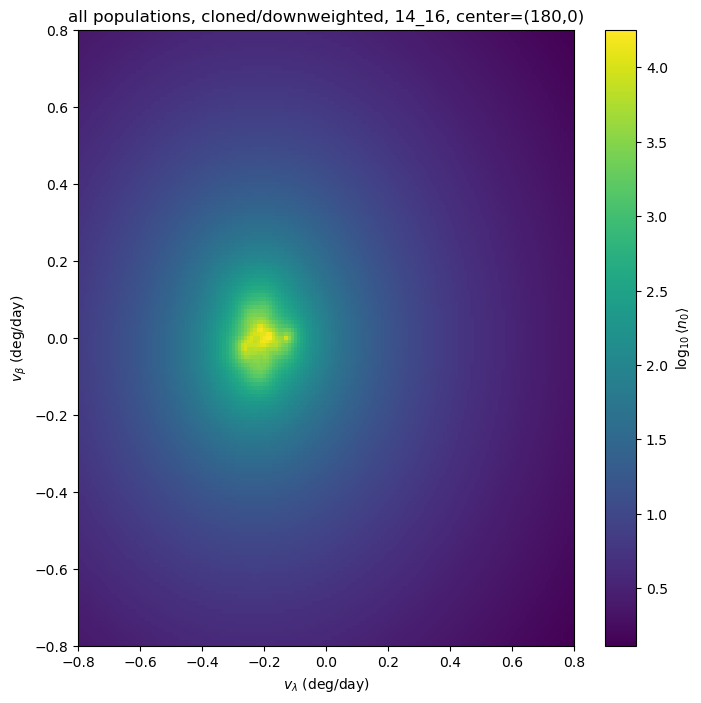

In [32]:
label = "14_16"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

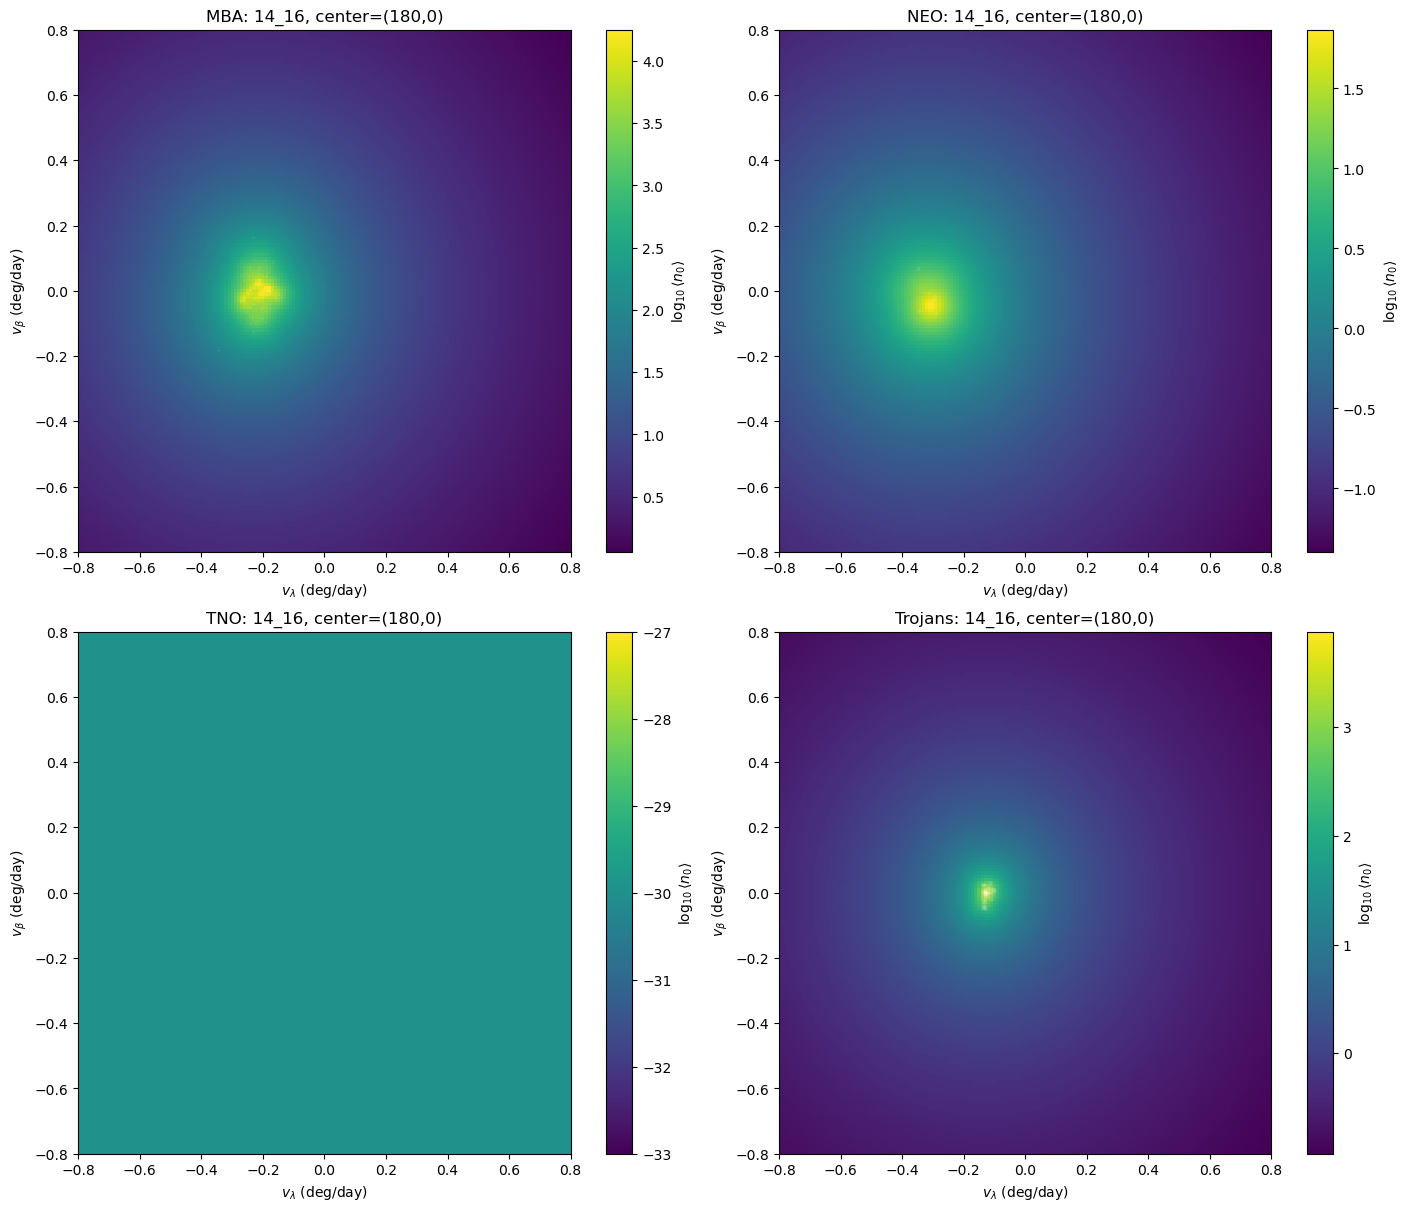

In [33]:
label = "14_16"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

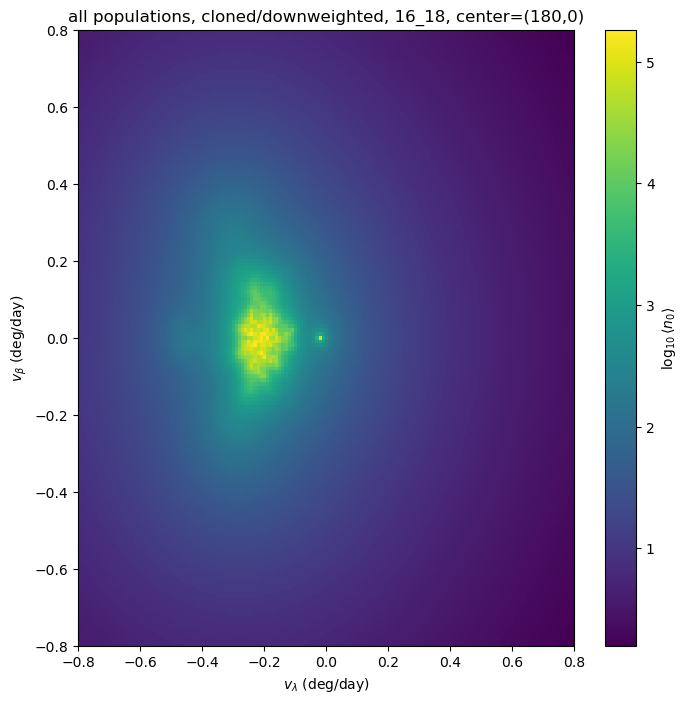

In [34]:
label = "16_18"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

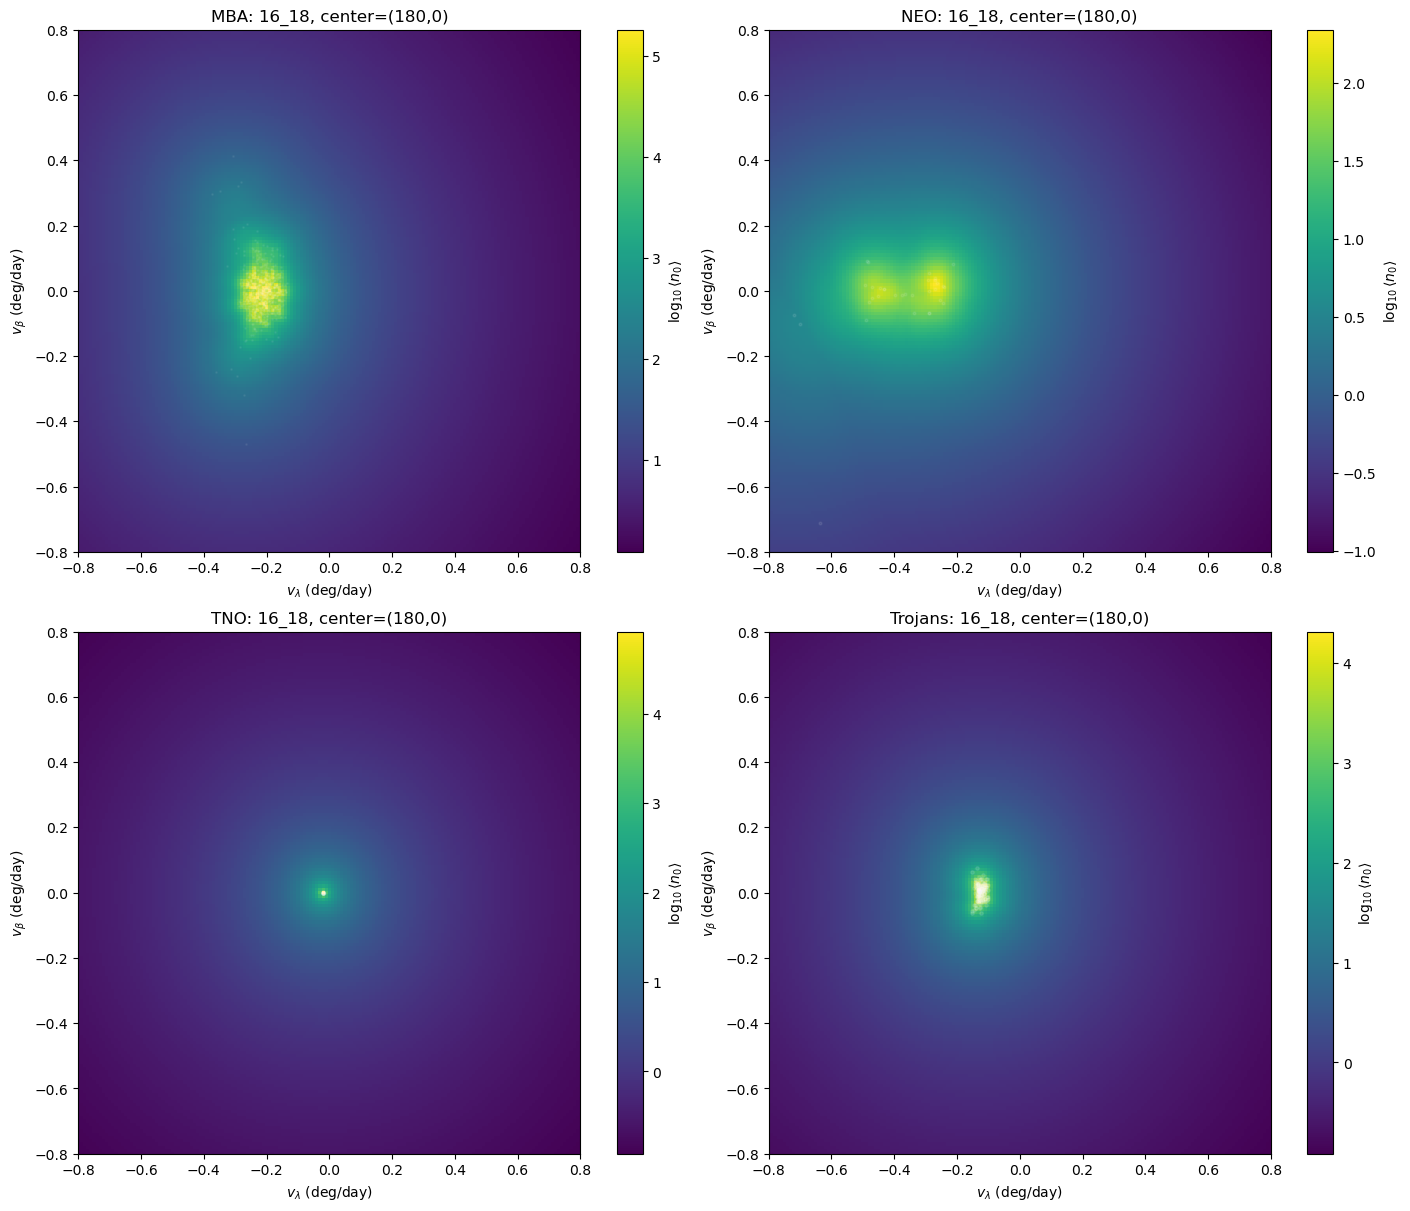

In [35]:
label = "16_18"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

#### NEO H plots for 16-18

Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 14.51it/s]


Raw NEO count in mag bin 16-18: 97
H stats (min/median/max): 11.175 15.952 24.794


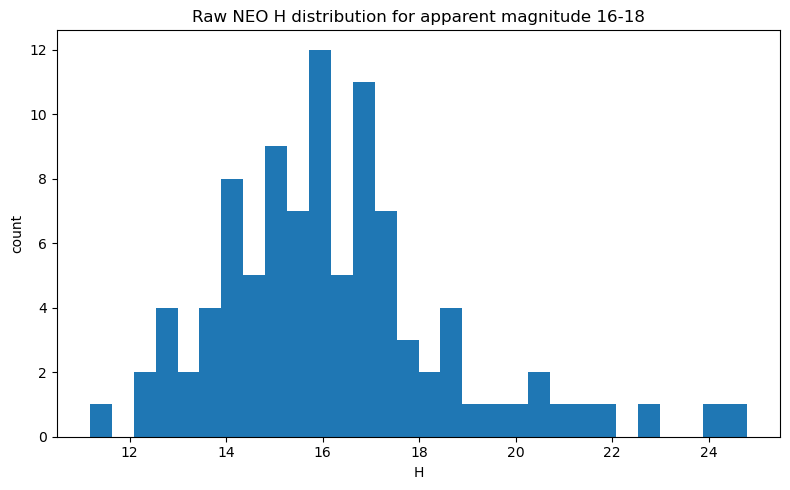

In [37]:
# NEO H distribution for the apparent-magnitude bin 16-18 (no cloning) 

neo_df = clone_sources["NEO"]["df"]
neo_scorer = clone_sources["NEO"]["scorer"]

# apparent magnitude for the full raw NEO population
mag_app_neo = compute_apparent_magnitude_for_population(
    df=neo_df,
    obstime_str=obstime_str,
    scorer=neo_scorer,
    chunk=100_000,
    show_progress=True,
)

# select raw NEOs with 16 <= mag_app < 18
neo_16_18_df, neo_16_18_mag = select_df_by_mag_bin(
    neo_df,
    mag_app_neo,
    mag_min=16.0,
    mag_max=18.0,
)

# pull H for those selected raw objects
H_neo_16_18 = neo_16_18_df["H"].to_numpy(dtype=float)

print("Raw NEO count in mag bin 16-18:", len(neo_16_18_df))
print("H stats (min/median/max):",
      np.nanmin(H_neo_16_18),
      np.nanmedian(H_neo_16_18),
      np.nanmax(H_neo_16_18))

# histogram of H
plt.figure(figsize=(8, 5))
plt.hist(H_neo_16_18[np.isfinite(H_neo_16_18)], bins=30)
plt.xlabel("H")
plt.ylabel("count")
plt.title("Raw NEO H distribution for apparent magnitude 16-18")
plt.tight_layout()
plt.show()

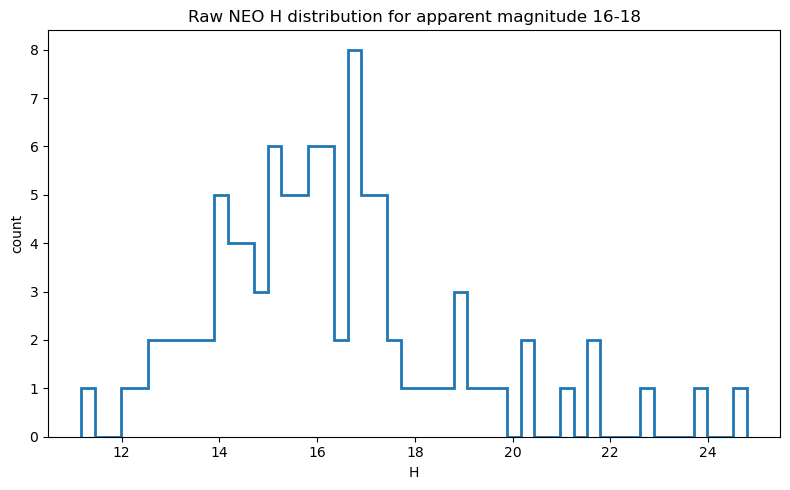

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(
    H_neo_16_18[np.isfinite(H_neo_16_18)],
    bins=50,
    histtype="step",
    linewidth=2,
)
plt.xlabel("H")
plt.ylabel("count")
plt.title("Raw NEO H distribution for apparent magnitude 16-18")
plt.tight_layout()
plt.show()

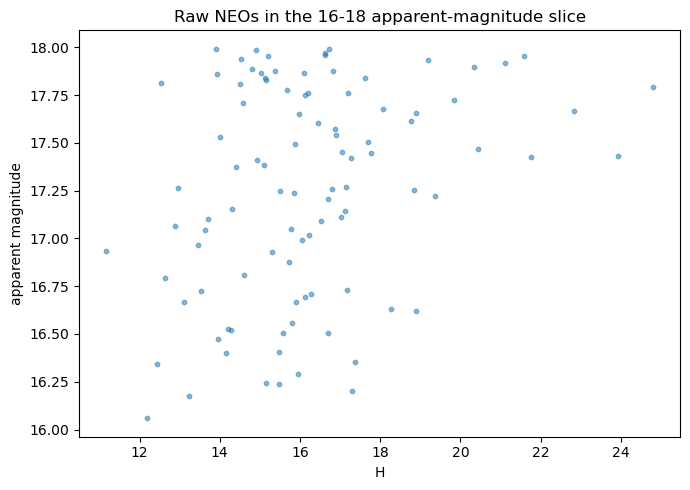

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(
    neo_16_18_df["H"].to_numpy(dtype=float),
    neo_16_18_mag,
    s=10,
    alpha=0.5,
)
plt.xlabel("H")
plt.ylabel("apparent magnitude")
plt.title("Raw NEOs in the 16-18 apparent-magnitude slice")
plt.tight_layout()
plt.show()

Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 14.75it/s]


NEOs in 16-18: 97


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 2379.07it/s]


d stats (AU): 0.023954404160808667 1.1685472270816009 3.4084184607858985
ddot stats (km/s): -195.3126114438388 1.9352031251924304 133.0962802904622


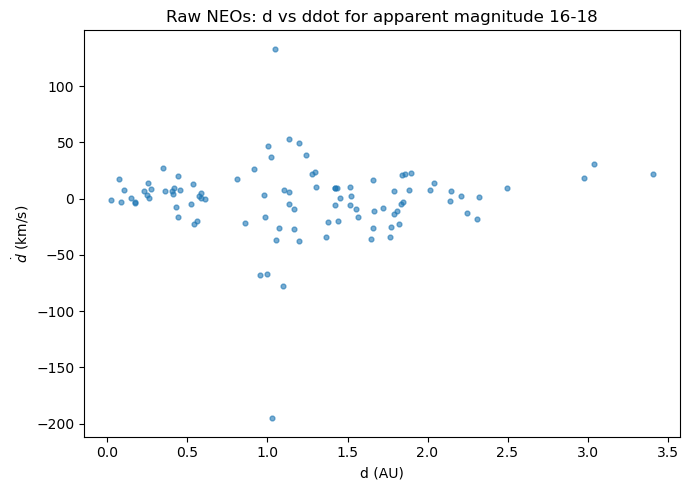

In [40]:
# NEO d vs ddot for apparent mag 16-18 no cloning) 

neo_df = clone_sources["NEO"]["df"]
neo_scorer = clone_sources["NEO"]["scorer"]

# apparent magnitude on the full raw NEO population
mag_app_neo = compute_apparent_magnitude_for_population(
    df=neo_df,
    obstime_str=obstime_str,
    scorer=neo_scorer,
    chunk=100_000,
    show_progress=True,
)

#  select raw NEOs with 16 <= mag_app < 18
neo_cut_df, neo_cut_mag = select_df_by_mag_bin(
    neo_df,
    mag_app_neo,
    mag_min=16.0,
    mag_max=18.0,
)

print("NEOs in 16-18:", len(neo_cut_df))

# propagate selected raw NEOs to heliocentric ecliptic state
r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=neo_cut_df["a"].to_numpy(dtype=float),
    e=neo_cut_df["e"].to_numpy(dtype=float),
    inc_deg=neo_cut_df["i"].to_numpy(dtype=float),
    raan_deg=neo_cut_df["node"].to_numpy(dtype=float),
    argp_deg=neo_cut_df["argperi"].to_numpy(dtype=float),
    tp_mjd=neo_cut_df["t_p"].to_numpy(dtype=float),
    obstime_str=obstime_str,
    method="newton",
    n_iter=10,
    chunk=100_000,
    show_progress=True,
)

#  rotate ecliptic -> equatorial 
eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_eq = np.column_stack([
    r_ecl[:, 0],
    c * r_ecl[:, 1] - s * r_ecl[:, 2],
    s * r_ecl[:, 1] + c * r_ecl[:, 2],
])

v_eq = np.column_stack([
    v_ecl[:, 0],
    c * v_ecl[:, 1] - s * v_ecl[:, 2],
    s * v_ecl[:, 1] + c * v_ecl[:, 2],
])

#  Earth + observatory state from scorer
obstime, rE, vE, r_tele = neo_scorer._get_earth_and_observer(obstime_str)

# topocentric relative state 
r_rel = r_eq - (rE + r_tele)
v_rel = v_eq - vE

# distance d and radial velocity ddot
d_km = np.linalg.norm(r_rel, axis=1)
ddot_kms = np.sum(r_rel * v_rel, axis=1) / d_km

# convert distance to AU for plotting
AU_KM = 149597870.7
d_au = d_km / AU_KM

print("d stats (AU):", np.nanmin(d_au), np.nanmedian(d_au), np.nanmax(d_au))
print("ddot stats (km/s):", np.nanmin(ddot_kms), np.nanmedian(ddot_kms), np.nanmax(ddot_kms))

#  plot
plt.figure(figsize=(7, 5))
plt.scatter(d_au, ddot_kms, s=12, alpha=0.6)
plt.xlabel("d (AU)")
plt.ylabel(r"$\dot d$ (km/s)")
plt.title("Raw NEOs: d vs ddot for apparent magnitude 16-18")
plt.tight_layout()
plt.show()

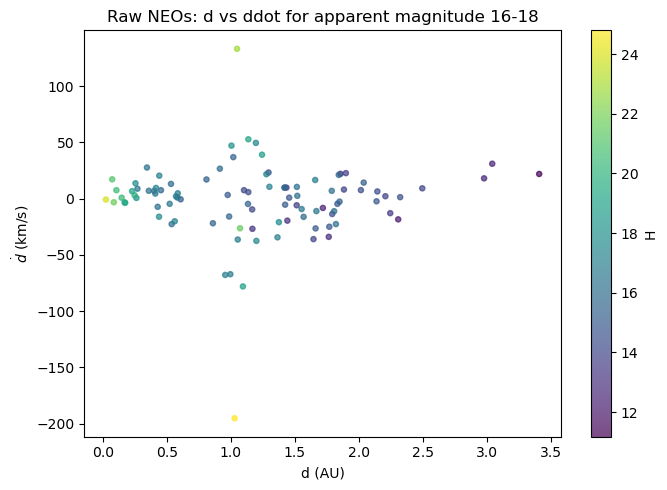

In [41]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    d_au,
    ddot_kms,
    c=neo_cut_df["H"].to_numpy(dtype=float),
    s=14,
    alpha=0.7,
)
plt.xlabel("d (AU)")
plt.ylabel(r"$\dot d$ (km/s)")
plt.title("Raw NEOs: d vs ddot for apparent magnitude 16-18")
plt.colorbar(sc, label="H")
plt.tight_layout()
plt.show()

In [45]:
len(clone_sources["NEO"]["df"])
mag_app_neo[:10]
np.nanmin(mag_app_neo), np.nanmedian(mag_app_neo), np.nanmax(mag_app_neo)

(11.763092387514835, 28.15799748948699, 96.39511918878893)

#### MBAs H plots for 16-18

Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.01it/s]


Raw MBA count in mag bin 16-18: 10357
H stats (min/median/max): 8.2 13.07 17.81


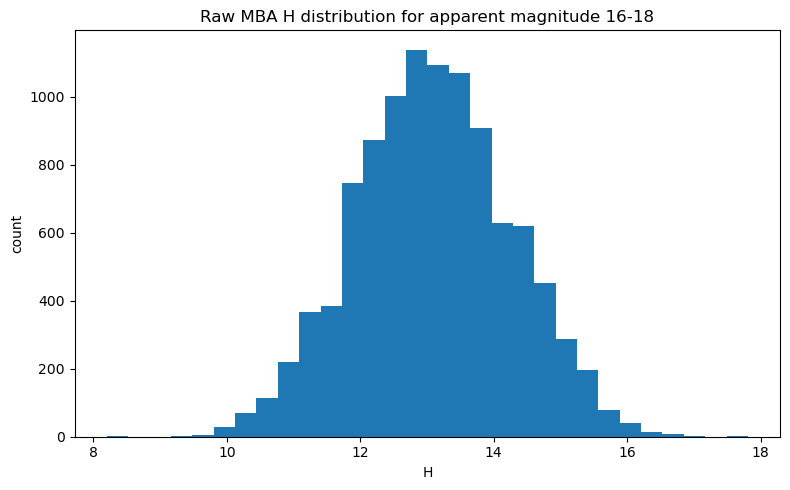

In [47]:
# MBA H distribution for the apparent-magnitude bin 16-18 (no cloning) 

mba_df = clone_sources["MBA"]["df"]
mba_scorer = clone_sources["MBA"]["scorer"]

# apparent magnitude for the full raw NEO population
mag_app_mba = compute_apparent_magnitude_for_population(
    df=mba_df,
    obstime_str=obstime_str,
    scorer=mba_scorer,
    chunk=100_000,
    show_progress=True,
)

# select raw MBAs with 16 <= mag_app < 18
mba_16_18_df, mba_16_18_mag = select_df_by_mag_bin(
    mba_df,
    mag_app_mba,
    mag_min=16.0,
    mag_max=18.0,
)

# pull H for those selected raw objects
H_mba_16_18 = mba_16_18_df["H"].to_numpy(dtype=float)

print("Raw MBA count in mag bin 16-18:", len(mba_16_18_df))
print("H stats (min/median/max):",
      np.nanmin(H_mba_16_18),
      np.nanmedian(H_mba_16_18),
      np.nanmax(H_mba_16_18))

# histogram of H
plt.figure(figsize=(8, 5))
plt.hist(H_mba_16_18[np.isfinite(H_mba_16_18)], bins=30)
plt.xlabel("H")
plt.ylabel("count")
plt.title("Raw MBA H distribution for apparent magnitude 16-18")
plt.tight_layout()
plt.show()

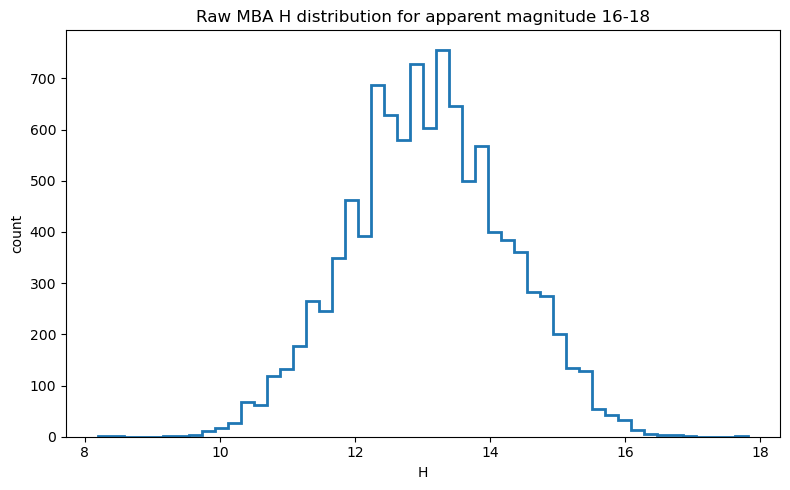

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(
    H_mba_16_18[np.isfinite(H_mba_16_18)],
    bins=50,
    histtype="step",
    linewidth=2,
)
plt.xlabel("H")
plt.ylabel("count")
plt.title("Raw MBA H distribution for apparent magnitude 16-18")
plt.tight_layout()
plt.show()

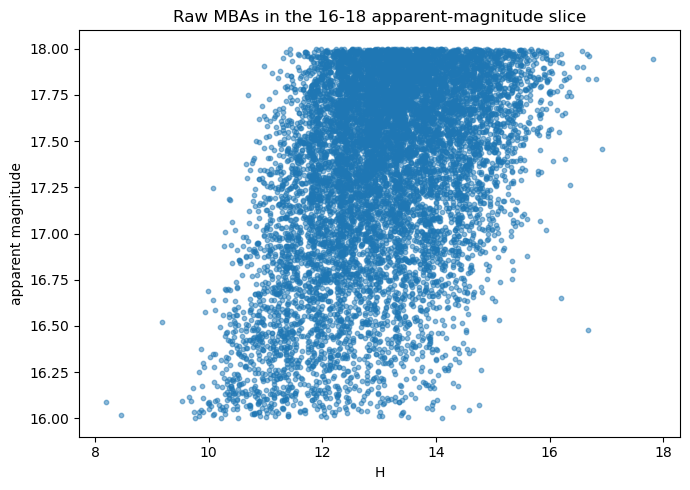

In [49]:
plt.figure(figsize=(7, 5))
plt.scatter(
    mba_16_18_df["H"].to_numpy(dtype=float),
    mba_16_18_mag,
    s=10,
    alpha=0.5,
)
plt.xlabel("H")
plt.ylabel("apparent magnitude")
plt.title("Raw MBAs in the 16-18 apparent-magnitude slice")
plt.tight_layout()
plt.show()

Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 12.47it/s]


MBAs in 16-18: 10357


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 118.53it/s]

d stats (AU): 0.45324547890419686 2.0110199066567116 5.5976612056808746
ddot stats (km/s): -28.85321356810357 -0.39198641121404854 30.234964619042618


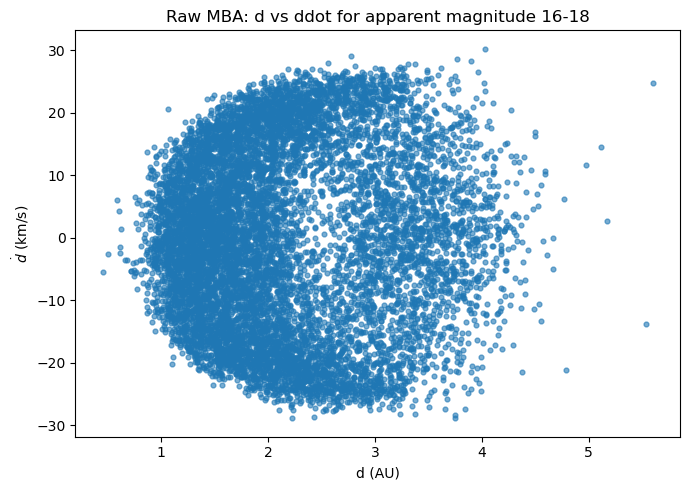

In [50]:
# MBA d vs ddot for apparent mag 16-18 no cloning) 

mba_df = clone_sources["MBA"]["df"]
mba_scorer = clone_sources["MBA"]["scorer"]

# apparent magnitude on the full raw MBA population
mag_app_mba = compute_apparent_magnitude_for_population(
    df=mba_df,
    obstime_str=obstime_str,
    scorer=mba_scorer,
    chunk=100_000,
    show_progress=True,
)

#  select raw MBAs with 16 <= mag_app < 18
mba_cut_df, mba_cut_mag = select_df_by_mag_bin(
    mba_df,
    mag_app_mba,
    mag_min=16.0,
    mag_max=18.0,
)

print("MBAs in 16-18:", len(mba_cut_df))

# propagate selected raw NEOs to heliocentric ecliptic state
r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=mba_cut_df["a"].to_numpy(dtype=float),
    e=mba_cut_df["e"].to_numpy(dtype=float),
    inc_deg=mba_cut_df["i"].to_numpy(dtype=float),
    raan_deg=mba_cut_df["node"].to_numpy(dtype=float),
    argp_deg=mba_cut_df["argperi"].to_numpy(dtype=float),
    tp_mjd=mba_cut_df["t_p"].to_numpy(dtype=float),
    obstime_str=obstime_str,
    method="newton",
    n_iter=10,
    chunk=100_000,
    show_progress=True,
)

#  rotate ecliptic -> equatorial 
eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_eq = np.column_stack([
    r_ecl[:, 0],
    c * r_ecl[:, 1] - s * r_ecl[:, 2],
    s * r_ecl[:, 1] + c * r_ecl[:, 2],
])

v_eq = np.column_stack([
    v_ecl[:, 0],
    c * v_ecl[:, 1] - s * v_ecl[:, 2],
    s * v_ecl[:, 1] + c * v_ecl[:, 2],
])

#  Earth + observatory state from scorer
obstime, rE, vE, r_tele = mba_scorer._get_earth_and_observer(obstime_str)

# topocentric relative state 
r_rel = r_eq - (rE + r_tele)
v_rel = v_eq - vE

# distance d and radial velocity ddot
d_km = np.linalg.norm(r_rel, axis=1)
ddot_kms = np.sum(r_rel * v_rel, axis=1) / d_km

# convert distance to AU for plotting
AU_KM = 149597870.7
d_au = d_km / AU_KM

print("d stats (AU):", np.nanmin(d_au), np.nanmedian(d_au), np.nanmax(d_au))
print("ddot stats (km/s):", np.nanmin(ddot_kms), np.nanmedian(ddot_kms), np.nanmax(ddot_kms))

#  plot
plt.figure(figsize=(7, 5))
plt.scatter(d_au, ddot_kms, s=12, alpha=0.6)
plt.xlabel("d (AU)")
plt.ylabel(r"$\dot d$ (km/s)")
plt.title("Raw MBA: d vs ddot for apparent magnitude 16-18")
plt.tight_layout()
plt.show()

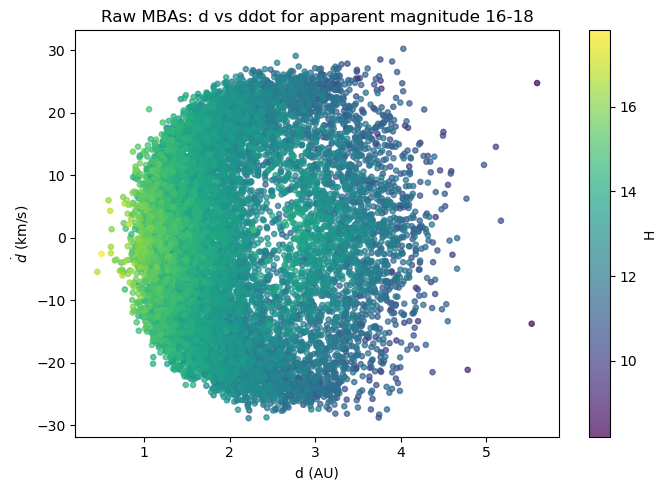

In [51]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    d_au,
    ddot_kms,
    c=mba_cut_df["H"].to_numpy(dtype=float),
    s=14,
    alpha=0.7,
)
plt.xlabel("d (AU)")
plt.ylabel(r"$\dot d$ (km/s)")
plt.title("Raw MBAs: d vs ddot for apparent magnitude 16-18")
plt.colorbar(sc, label="H")
plt.tight_layout()
plt.show()

Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 12.56it/s]


Raw MBA count in mag bin 16_18: 10357


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 114.68it/s]

Final usable objects: 10357
d stats (AU): 0.45324547890419686 2.0110199066567116 5.5976612056808746
H stats: 8.2 13.07 17.81
d < 0.7 AU: 9
d > 0.7 AU: 10348


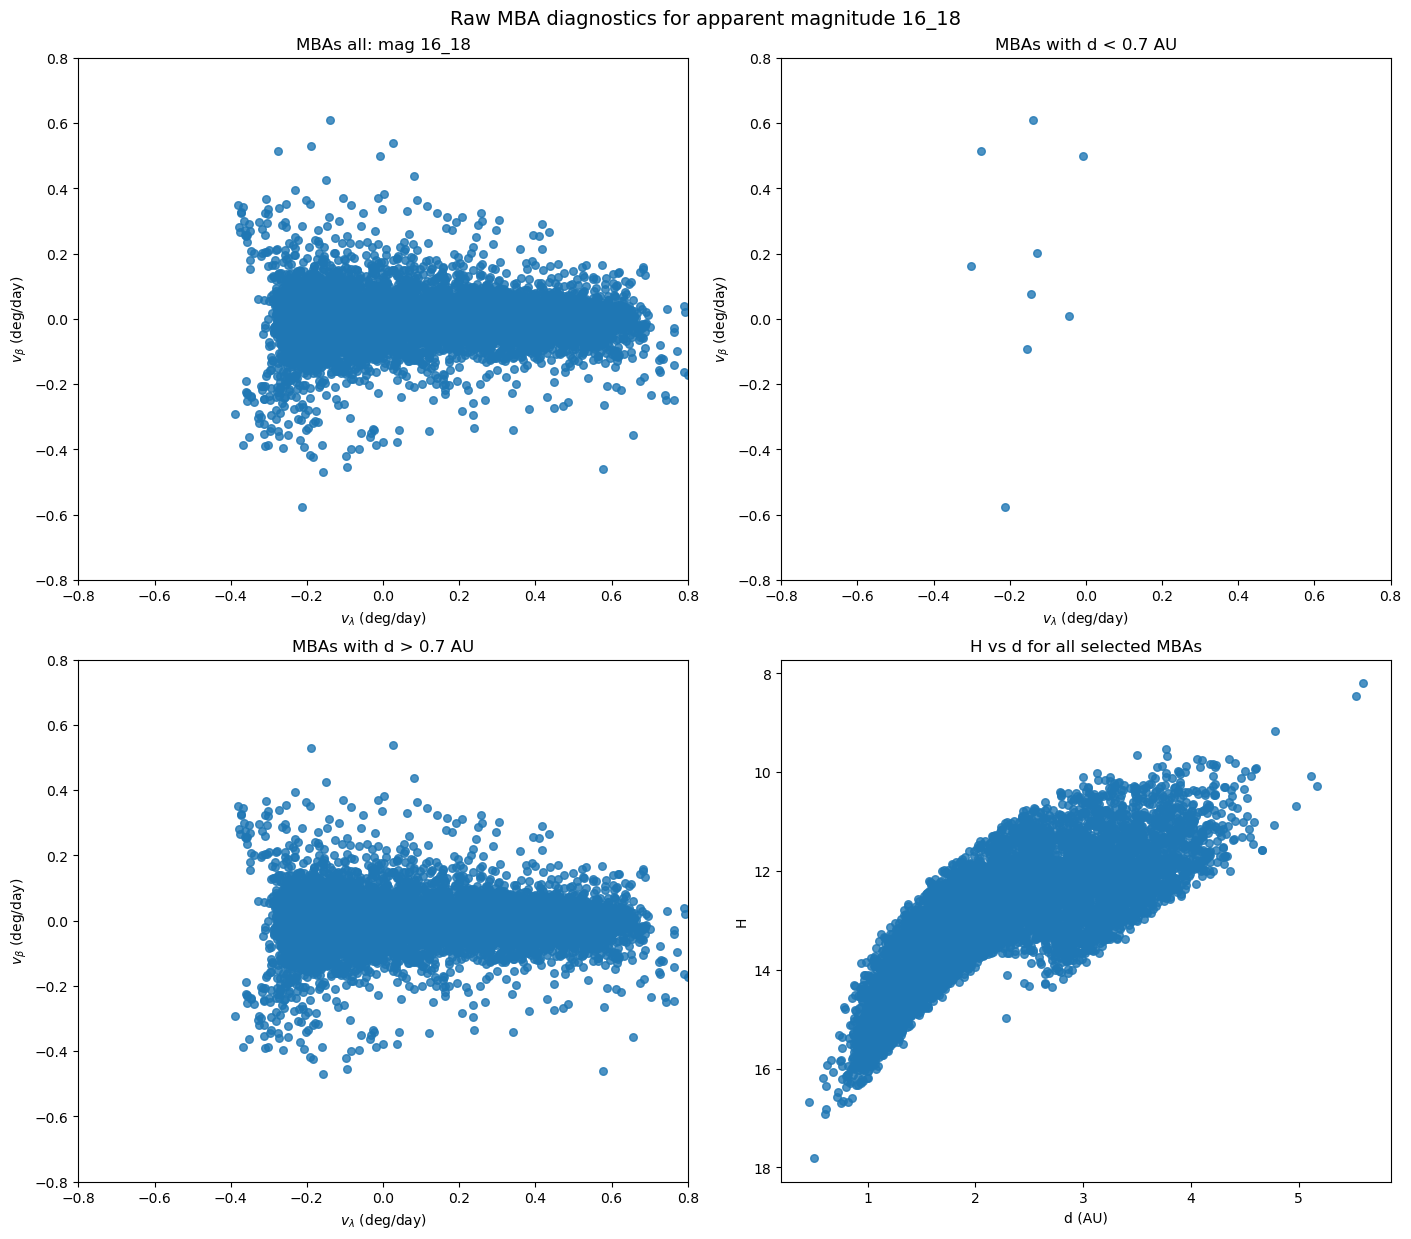

In [54]:
# 4 plots for one raw population apparent-magnitude bin 
#   (1) all objects in v_beta vs v_lambda
#   (2) only d < d_split_au in v_beta vs v_lambda
#   (3) only d > d_split_au in v_beta vs v_lambda
#   (4) H vs d for all objects
#
# This uses raw objects (no cloning), after apparent-magnitude cut.


pop_name = "MBA"          # change to "NEO", "MBA", "TNO", "Trojans"
mag_min = 16.0
mag_max = 18.0
mag_label = "16_18"
d_split_au = 0.7
Nplot = 300_000


pop_df = clone_sources[pop_name]["df"]
pop_scorer = clone_sources[pop_name]["scorer"]

# apparent magnitude on the full raw population
mag_app = compute_apparent_magnitude_for_population(
    df=pop_df,
    obstime_str=obstime_str,
    scorer=pop_scorer,
    chunk=100_000,
    show_progress=True,
)

# raw objects in this apparent-magnitude bin
cut_df, cut_mag = select_df_by_mag_bin(
    pop_df,
    mag_app,
    mag_min=mag_min,
    mag_max=mag_max,
)

print(f"Raw {pop_name} count in mag bin {mag_label}: {len(cut_df)}")

#  propagate those raw selected objects
r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=cut_df["a"].to_numpy(dtype=float),
    e=cut_df["e"].to_numpy(dtype=float),
    inc_deg=cut_df["i"].to_numpy(dtype=float),
    raan_deg=cut_df["node"].to_numpy(dtype=float),
    argp_deg=cut_df["argperi"].to_numpy(dtype=float),
    tp_mjd=cut_df["t_p"].to_numpy(dtype=float),
    obstime_str=obstime_str,
    method="newton",
    n_iter=10,
    chunk=100_000,
    show_progress=True,
)

#  rotate ecliptic -> equatorial
eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_eq = np.column_stack([
    r_ecl[:, 0],
    c * r_ecl[:, 1] - s * r_ecl[:, 2],
    s * r_ecl[:, 1] + c * r_ecl[:, 2],
])

v_eq = np.column_stack([
    v_ecl[:, 0],
    c * v_ecl[:, 1] - s * v_ecl[:, 2],
    s * v_ecl[:, 1] + c * v_ecl[:, 2],
])

# Earth + observer state
obstime, rE, vE, r_tele = pop_scorer._get_earth_and_observer(obstime_str)

#  topocentric relative state
r_rel = r_eq - (rE + r_tele)
v_rel = v_eq - vE

#  RA/Dec + rates
x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra   = np.arctan2(y, x)
dec  = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

#  convert to ecliptic angular rates
ra_deg = np.rad2deg(ra[good]) % 360.0
dec_deg = np.rad2deg(dec[good])
dra_deg_day = np.rad2deg(dra[good]) * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg,
    dec_deg,
    dra_deg_day,
    ddec_deg_day,
    obstime_str,
)

# distance d and H for the same surviving objects
AU_KM = 149597870.7

d_km = np.linalg.norm(r_rel[good], axis=1)
d_au = d_km / AU_KM

H_all = cut_df["H"].to_numpy(dtype=float)
H_use = H_all[good]

finite = np.isfinite(vlam) & np.isfinite(vbeta) & np.isfinite(d_au) & np.isfinite(H_use)
vlam = vlam[finite]
vbeta = vbeta[finite]
d_au = d_au[finite]
H_use = H_use[finite]

print("Final usable objects:", len(vlam))
print("d stats (AU):", np.nanmin(d_au), np.nanmedian(d_au), np.nanmax(d_au))
print("H stats:", np.nanmin(H_use), np.nanmedian(H_use), np.nanmax(H_use))

#  split by distance
near = d_au < d_split_au
far  = d_au > d_split_au

print(f"d < {d_split_au:.1f} AU:", np.sum(near))
print(f"d > {d_split_au:.1f} AU:", np.sum(far))

#  downsample for plotting only
rng = np.random.default_rng(42)

def downsample_xy(x, y, nmax):
    if len(x) > nmax:
        idx = rng.choice(len(x), size=nmax, replace=False)
        return x[idx], y[idx]
    return x, y

def downsample_xyz(x, y, z, nmax):
    if len(x) > nmax:
        idx = rng.choice(len(x), size=nmax, replace=False)
        return x[idx], y[idx], z[idx]
    return x, y, z

vlam_all, vbeta_all = downsample_xy(vlam, vbeta, Nplot)
vlam_near, vbeta_near = downsample_xy(vlam[near], vbeta[near], Nplot)
vlam_far, vbeta_far = downsample_xy(vlam[far], vbeta[far], Nplot)
d_plot, H_plot, _ = downsample_xyz(d_au, H_use, H_use, Nplot)


fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

# all
axes[0].scatter(vlam_all, vbeta_all, s=30, alpha=0.8)
axes[0].set_title(f"{pop_name}s all: mag {mag_label}")
axes[0].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[0].set_ylabel(r"$v_\beta$ (deg/day)")
axes[0].set_xlim(-0.8, 0.8)
axes[0].set_ylim(-0.8, 0.8)

# near
axes[1].scatter(vlam_near, vbeta_near, s=30, alpha=0.8)
axes[1].set_title(f"{pop_name}s with d < {d_split_au:.1f} AU")
axes[1].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[1].set_ylabel(r"$v_\beta$ (deg/day)")
axes[1].set_xlim(-0.8, 0.8)
axes[1].set_ylim(-0.8, 0.8)

# far
axes[2].scatter(vlam_far, vbeta_far, s=30, alpha=0.8)
axes[2].set_title(f"{pop_name}s with d > {d_split_au:.1f} AU")
axes[2].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[2].set_ylabel(r"$v_\beta$ (deg/day)")
axes[2].set_xlim(-0.8, 0.8)
axes[2].set_ylim(-0.8, 0.8)

# H vs d
axes[3].scatter(d_plot, H_plot, s=30, alpha=0.8)
axes[3].set_title(f"H vs d for all selected {pop_name}s")
axes[3].set_xlabel("d (AU)")
axes[3].set_ylabel("H")
axes[3].invert_yaxis()

plt.suptitle(f"Raw {pop_name} diagnostics for apparent magnitude {mag_label}", y=1.02, fontsize=14)
plt.show()

Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 12.41it/s]


Objects in anti-sun patch and mag 16-18: 3224


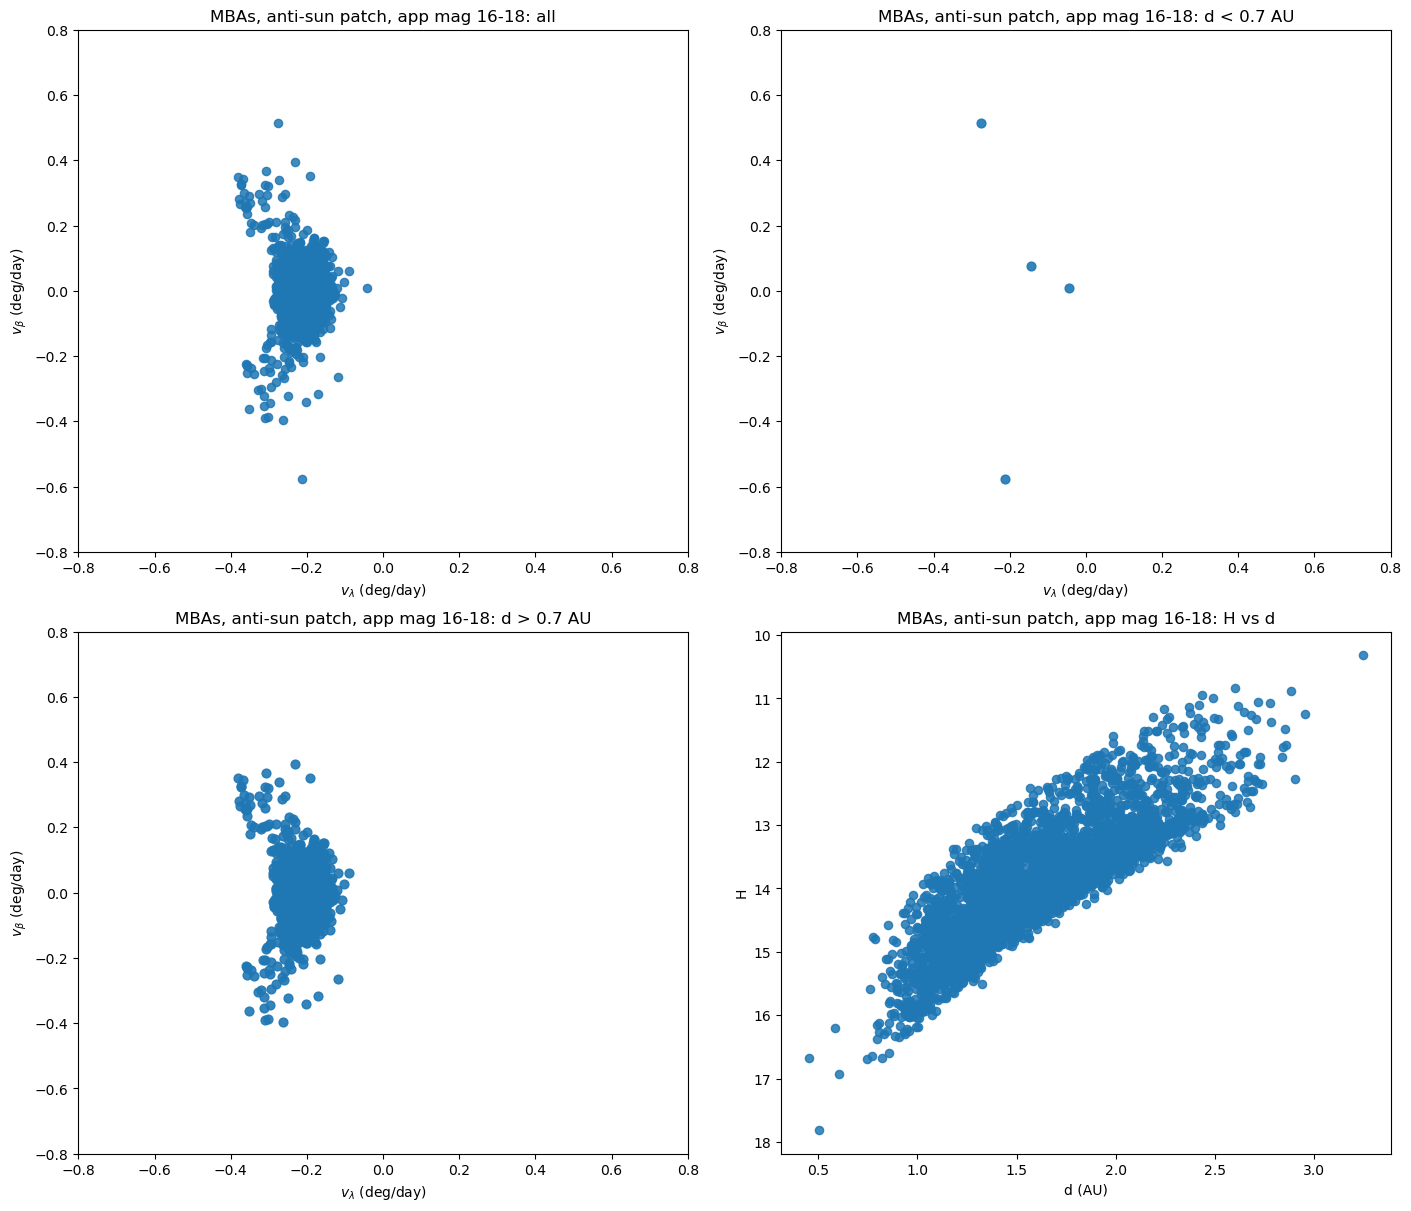

In [56]:
def get_raw_patch_selected_mba_sample(
    df,
    scorer,
    obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=20.0,
    chunk=100_000,
    show_progress=True,
):
    """
    Return raw MBA sample restricted to the selected sky patch, with:
      vlam, vbeta, d_au, H, mag_app
    """

    t_obs = Time(obstime_str, scale="tdb")

    # propagate to heliocentric ecliptic state
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    v_eq = np.column_stack([
        v_ecl[:, 0],
        c * v_ecl[:, 1] - s * v_ecl[:, 2],
        s * v_ecl[:, 1] + c * v_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative state
    r_rel = r_eq - (rE + r_tele)
    v_rel = v_eq - vE

    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    # anti-sun patch selection in sky position
    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    center_ecl = SkyCoord(
        lon=center_lon_deg * u.deg,
        lat=center_lat_deg * u.deg,
        distance=1.0 * u.AU,
        frame=GeocentricTrueEcliptic(obstime=t_obs),
    )
    center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    good_idx = np.flatnonzero(good)
    patch_idx = good_idx[m]

    # vlam, vbeta
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[m],
        dec_deg[m],
        dra_deg_day[m],
        ddec_deg_day[m],
        obstime_str,
    )

    # distances and H 
    AU_KM = 149597870.7

    r_obs_vec = r_eq[patch_idx] - (rE + r_tele)
    d_au = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    H = df["H"].to_numpy(dtype=float)[patch_idx]

    # apparent magnitude for patch sample only
    r_helio_vec = r_eq[patch_idx]
    r_sun = np.linalg.norm(r_helio_vec, axis=1) / AU_KM
    Delta = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)

    finite = (
        np.isfinite(vlam) &
        np.isfinite(vbeta) &
        np.isfinite(d_au) &
        np.isfinite(H) &
        np.isfinite(mag_app)
    )

    return {
        "vlam": np.asarray(vlam)[finite],
        "vbeta": np.asarray(vbeta)[finite],
        "d_au": d_au[finite],
        "H": H[finite],
        "mag_app": mag_app[finite],
    }

sample = get_raw_patch_selected_mba_sample(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    obstime_str=obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=max_sep_deg,
    chunk=100_000,
    show_progress=True,
)

# apparent-magnitude bin inside the anti-sun patch
mag_min, mag_max = 16.0, 18.0
sel = (sample["mag_app"] >= mag_min) & (sample["mag_app"] < mag_max)

vlam = sample["vlam"][sel]
vbeta = sample["vbeta"][sel]
d_au = sample["d_au"][sel]
H = sample["H"][sel]

print("Objects in anti-sun patch and mag 16-18:", len(vlam))

near = d_au < 0.7
far = d_au > 0.7

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

axes[0].scatter(vlam, vbeta, s=35, alpha=0.85)
axes[0].set_title("MBAs, anti-sun patch, app mag 16-18: all")
axes[0].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[0].set_ylabel(r"$v_\beta$ (deg/day)")
axes[0].set_xlim(-0.8, 0.8)
axes[0].set_ylim(-0.8, 0.8)

axes[1].scatter(vlam[near], vbeta[near], s=40, alpha=0.9)
axes[1].set_title("MBAs, anti-sun patch, app mag 16-18: d < 0.7 AU")
axes[1].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[1].set_ylabel(r"$v_\beta$ (deg/day)")
axes[1].set_xlim(-0.8, 0.8)
axes[1].set_ylim(-0.8, 0.8)

axes[2].scatter(vlam[far], vbeta[far], s=40, alpha=0.9)
axes[2].set_title("MBAs, anti-sun patch, app mag 16-18: d > 0.7 AU")
axes[2].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[2].set_ylabel(r"$v_\beta$ (deg/day)")
axes[2].set_xlim(-0.8, 0.8)
axes[2].set_ylim(-0.8, 0.8)

axes[3].scatter(d_au, H, s=35, alpha=0.85)
axes[3].set_title("MBAs, anti-sun patch, app mag 16-18: H vs d")
axes[3].set_xlabel("d (AU)")
axes[3].set_ylabel("H")
axes[3].invert_yaxis()

plt.show()

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, GeocentricTrueEcliptic

def get_raw_patch_selected_sample(
    df,
    scorer,
    obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=20.0,
    chunk=100_000,
    show_progress=True,
):
    """
    Return raw population sample restricted to the selected sky patch, with:
      vlam, vbeta, d_au, H, mag_app
    """

    t_obs = Time(obstime_str, scale="tdb")

    # propagate to heliocentric ecliptic state
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    v_eq = np.column_stack([
        v_ecl[:, 0],
        c * v_ecl[:, 1] - s * v_ecl[:, 2],
        s * v_ecl[:, 1] + c * v_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative state
    r_rel = r_eq - (rE + r_tele)
    v_rel = v_eq - vE

    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    # sky-patch selection in sky position
    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    center_ecl = SkyCoord(
        lon=center_lon_deg * u.deg,
        lat=center_lat_deg * u.deg,
        distance=1.0 * u.AU,
        frame=GeocentricTrueEcliptic(obstime=t_obs),
    )
    center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    good_idx = np.flatnonzero(good)
    patch_idx = good_idx[m]

    # vlam, vbeta for patch sample
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[m],
        dec_deg[m],
        dra_deg_day[m],
        ddec_deg_day[m],
        obstime_str,
    )

    # distances and H for patch sample
    AU_KM = 149597870.7

    r_obs_vec = r_eq[patch_idx] - (rE + r_tele)
    d_au = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    H = df["H"].to_numpy(dtype=float)[patch_idx]

    # apparent magnitude for patch sample only
    r_helio_vec = r_eq[patch_idx]
    r_sun = np.linalg.norm(r_helio_vec, axis=1) / AU_KM
    Delta = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)

    finite = (
        np.isfinite(vlam) &
        np.isfinite(vbeta) &
        np.isfinite(d_au) &
        np.isfinite(H) &
        np.isfinite(mag_app)
    )

    return {
        "vlam": np.asarray(vlam)[finite],
        "vbeta": np.asarray(vbeta)[finite],
        "d_au": d_au[finite],
        "H": H[finite],
        "mag_app": mag_app[finite],
    }

Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 12.44it/s]


MBA objects in anti-sun patch and mag bin mag22: 104356
d < 0.7 AU: 44
d > 0.7 AU: 104312


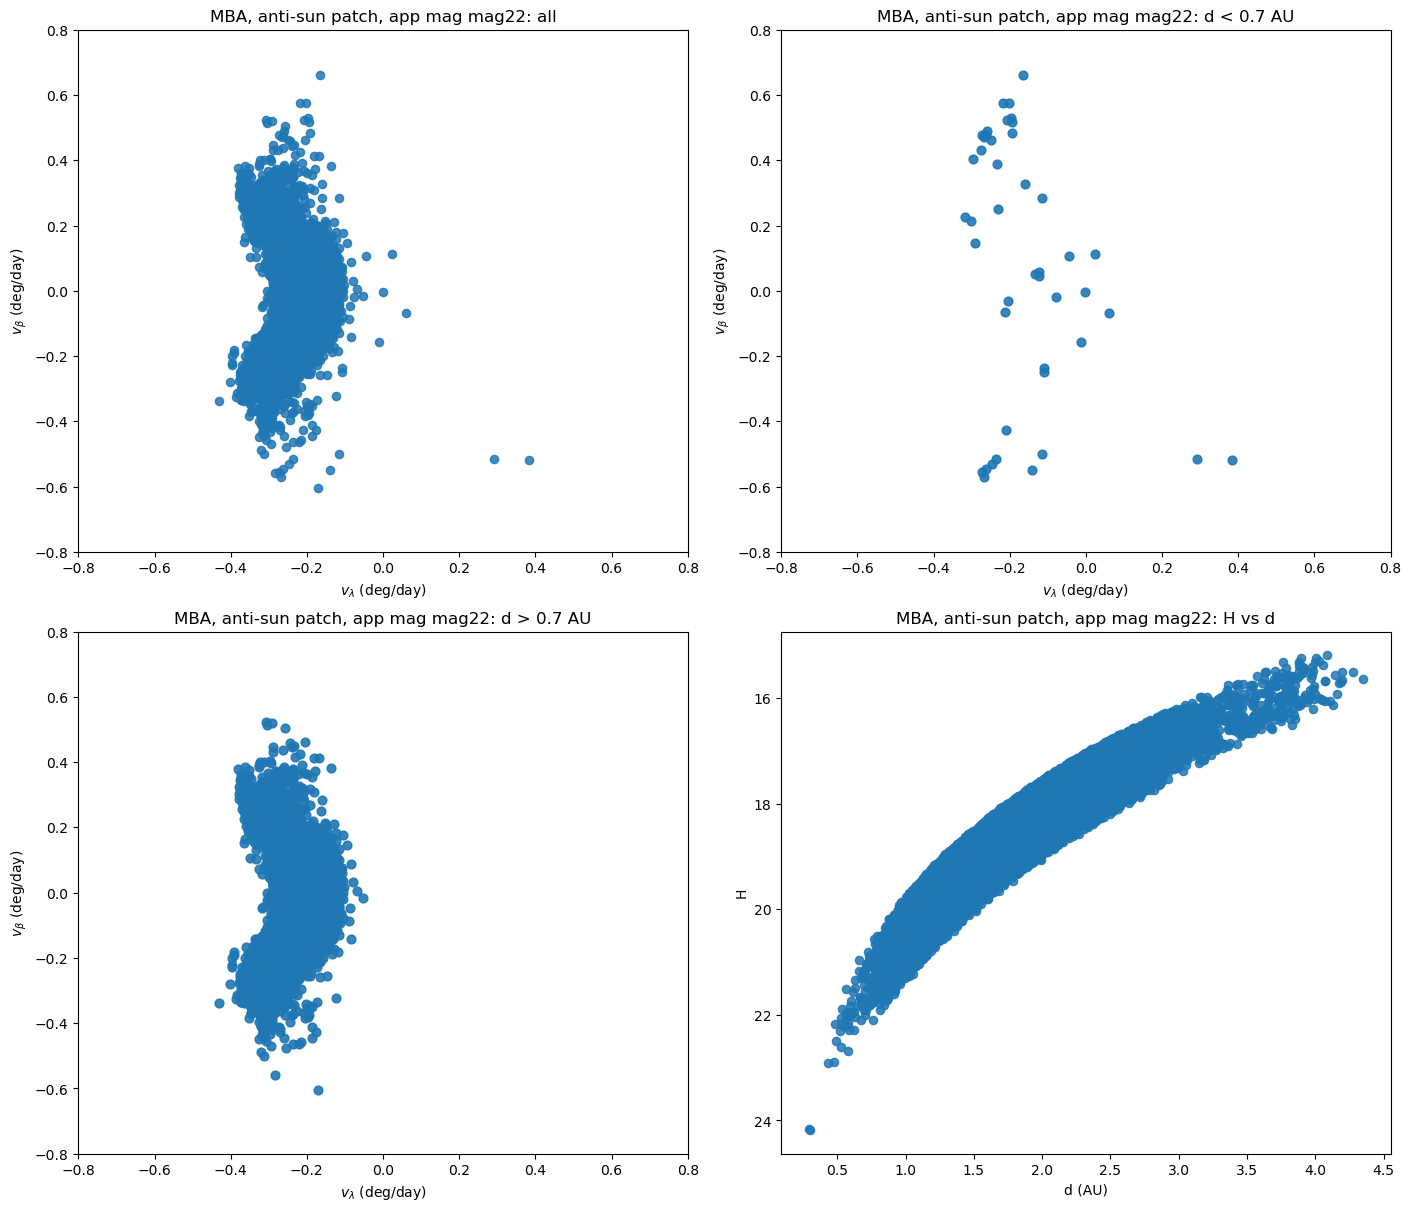

In [67]:
pop_name = "MBA"       # "NEO", "MBA", "TNO", "Trojans"
mbin = mag_bins[5]     # mag_bins[1] is 16_18 in list
d_split_au = 0.7


sample = get_raw_patch_selected_sample(
    df=clone_sources[pop_name]["df"],
    scorer=clone_sources[pop_name]["scorer"],
    obstime_str=obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=max_sep_deg,
    chunk=100_000,
    show_progress=True,
)

mag_min = mbin["mag_min"]
mag_max = mbin["mag_max"]
mag_label = mbin["label"]

# apparent magnitude bin inside the selected patch
sel = (sample["mag_app"] >= mag_min) & (sample["mag_app"] < mag_max)

vlam = sample["vlam"][sel]
vbeta = sample["vbeta"][sel]
d_au = sample["d_au"][sel]
H = sample["H"][sel]

print(f"{pop_name} objects in anti-sun patch and mag bin {mag_label}: {len(vlam)}")

near = d_au < d_split_au
far = d_au > d_split_au

print(f"d < {d_split_au:.1f} AU:", np.sum(near))
print(f"d > {d_split_au:.1f} AU:", np.sum(far))

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

axes[0].scatter(vlam, vbeta, s=35, alpha=0.85)
axes[0].set_title(f"{pop_name}, anti-sun patch, app mag {mag_label}: all")
axes[0].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[0].set_ylabel(r"$v_\beta$ (deg/day)")
axes[0].set_xlim(-0.8, 0.8)
axes[0].set_ylim(-0.8, 0.8)

axes[1].scatter(vlam[near], vbeta[near], s=40, alpha=0.9)
axes[1].set_title(f"{pop_name}, anti-sun patch, app mag {mag_label}: d < {d_split_au:.1f} AU")
axes[1].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[1].set_ylabel(r"$v_\beta$ (deg/day)")
axes[1].set_xlim(-0.8, 0.8)
axes[1].set_ylim(-0.8, 0.8)

axes[2].scatter(vlam[far], vbeta[far], s=40, alpha=0.9)
axes[2].set_title(f"{pop_name}, anti-sun patch, app mag {mag_label}: d > {d_split_au:.1f} AU")
axes[2].set_xlabel(r"$v_\lambda$ (deg/day)")
axes[2].set_ylabel(r"$v_\beta$ (deg/day)")
axes[2].set_xlim(-0.8, 0.8)
axes[2].set_ylim(-0.8, 0.8)

axes[3].scatter(d_au, H, s=35, alpha=0.85)
axes[3].set_title(f"{pop_name}, anti-sun patch, app mag {mag_label}: H vs d")
axes[3].set_xlabel("d (AU)")
axes[3].set_ylabel("H")
axes[3].invert_yaxis()

plt.show()